# Projeto Final - Analise de eventos LHE

## Parte 1: Leitura do LHE para `pandas.DataFrame`

Este notebook e uma opcao de trabalho para estudantes. Ele nao contem codigo
pronto.

A ideia e usar cada celula de instrucao para pedir a um agente que gere o codigo
correspondente ao metodo **dataframe**. Depois, copie o codigo produzido pelo
agente para a celula vazia logo abaixo e execute no seu ambiente.

Arquivos da amostra:

- sinal: `../data/sinal.lhe.gz`;
- fundo: `../data/fundo.lhe.gz`.

Mantenha as respostas, tabelas, figuras e interpretacoes no proprio notebook.


## 0. Preparação no Google Colab

Antes de iniciar a análise, siga este fluxo no ambiente do Google Colab:

1. No GitHub, baixe o arquivo ZIP deste repositório (**Code → Download ZIP**) e baixe também o notebook desta tarefa que você vai executar.
2. Abra o notebook no Colab e use o painel **Arquivos** para fazer upload do arquivo `.ipynb` e do arquivo `.zip`. O ZIP deve ficar no mesmo ambiente de execução do notebook, como arquivo de dados.
3. Peça ao agente para gerar e executar um código que localize o ZIP enviado, descompacte o repositório no ambiente do Colab e entre na pasta extraída.
4. Em seguida, peça ao agente para gerar e executar um código que infle (descomprima com `gzip`) `data/sinal.lhe.gz` e `data/fundo.lhe.gz`, criando `data/sinal.lhe` e `data/fundo.lhe`. Mantenha os arquivos `.lhe.gz` originais.
5. Confirme com o agente que a pasta `data/` contém os dois arquivos compactados e as duas versões infladas antes de prosseguir.

Depois dessa preparação, peça ao agente os códigos de cada etapa indicada neste notebook e copie-os nas células de código correspondentes. Use a pasta extraída como diretório de trabalho e mantenha os caminhos relativos aos arquivos de dados.

In [43]:
!unzip -o /content/tarefa5-main.zip
!ls -R

Archive:  /content/tarefa5-main.zip
cc7f148f40821192548c07f7f0a450870272a176
  inflating: tarefa5-main/.gitignore  
  inflating: tarefa5-main/README.md  
  inflating: tarefa5-main/data/fundo.lhe.gz  
  inflating: tarefa5-main/data/sinal.lhe.gz  
  inflating: tarefa5-main/data/sobre_lhe.txt  
  inflating: tarefa5-main/instrucoes.txt  
  inflating: tarefa5-main/notebooks/01_leitura_texto.ipynb  
  inflating: tarefa5-main/notebooks/01_leitura_texto_parte2.ipynb  
  inflating: tarefa5-main/notebooks/02_leitura_pylhe.ipynb  
  inflating: tarefa5-main/notebooks/02_leitura_pylhe_parte2.ipynb  
  inflating: tarefa5-main/notebooks/03_leitura_dataframe.ipynb  
  inflating: tarefa5-main/notebooks/03_leitura_dataframe_parte2.ipynb  
  inflating: tarefa5-main/notebooks/README.md  
  inflating: tarefa5-main/notebooks/analise_parte1.ipynb  
  inflating: tarefa5-main/parte1.txt  
  inflating: tarefa5-main/parte2.txt  
  inflating: tarefa5-main/resultados/graficos/README.md  
.:
sample_data  tarefa5-ma

## 1. Leitura dos arquivos LHE

Objetivo: implementar a leitura das amostras de sinal e fundo usando o metodo
designado para este notebook: **Leitura do LHE para `pandas.DataFrame`**.

Nesta versao, a leitura deve produzir tabelas em `pandas.DataFrame`.

Peca ao agente para gerar codigo que leia os eventos e construa, no minimo, duas
tabelas:

- uma tabela de eventos, com amostra, indice do evento, `NUP`, escala
  e acoplamentos;
- uma tabela de particulas, com amostra, evento, PDG ID, `status`, maes, cor,
  `px`, `py`, `pz`, energia, massa, `pT`, `eta` e `phi`.

As etapas de validacao, histogramas e cutflow devem usar filtros, `groupby`,
agregacoes e merges de DataFrame sempre que possivel.

O codigo deve extrair, no minimo:

- cabecalho de cada evento;
- `NUP`;
- PDG ID;
- `status`;
- particulas-mae;
- `px`, `py`, `pz`, energia e massa.

Antes de implementar o parser, peça ao agente uma célula que abra `data/sinal.lhe.gz` e imprima o primeiro bloco completo entre `<event>` e `</event>`. Use essa inspeção para reconhecer o cabeçalho e as linhas das partículas.\n\nCole o codigo gerado na celula vazia abaixo.


In [44]:
import gzip
import pandas as pd
import numpy as np

def parse_lhe(file_path, sample_label):
    """Parses a compressed LHE file into two pandas DataFrames."""
    events = []
    particles = []

    with gzip.open(file_path, 'rt') as f:
        event_id = 0
        lines = f.readlines()
        i = 0
        while i < len(lines):
            line = lines[i].strip()
            if line == '<event>':
                # Event header line
                i += 1
                header = lines[i].split()
                n_part = int(header[0])
                events.append({
                    'sample': sample_label,
                    'event_idx': event_id,
                    'nup': n_part,
                    'scale': float(header[3]),
                    'aqed': float(header[4]),
                    'aqcd': float(header[5])
                })

                # Particle lines
                for _ in range(n_part):
                    i += 1
                    p_info = lines[i].split()
                    px, py, pz = float(p_info[6]), float(p_info[7]), float(p_info[8])
                    energy = float(p_info[9])
                    mass = float(p_info[10])

                    # Kinematics
                    pt = np.sqrt(px**2 + py**2)
                    p = np.sqrt(px**2 + py**2 + pz**2)
                    eta = 0.5 * np.log((p + pz) / (p - pz)) if p > abs(pz) else 0
                    phi = np.arctan2(py, px)

                    particles.append({
                        'sample': sample_label,
                        'event_idx': event_id,
                        'pdg_id': int(p_info[0]),
                        'status': int(p_info[1]),
                        'moth1': int(p_info[2]),
                        'moth2': int(p_info[3]),
                        'px': px, 'py': py, 'pz': pz,
                        'energy': energy, 'mass': mass,
                        'pt': pt, 'eta': eta, 'phi': phi
                    })
                event_id += 1
            i += 1

    return pd.DataFrame(events), pd.DataFrame(particles)

# Load datasets
df_ev_sinal, df_part_sinal = parse_lhe('tarefa5-main/data/sinal.lhe.gz', 'sinal')
df_ev_fundo, df_part_fundo = parse_lhe('tarefa5-main/data/fundo.lhe.gz', 'fundo')

# Combine data
df_events = pd.concat([df_ev_sinal, df_ev_fundo], ignore_index=True)
df_particles = pd.concat([df_part_sinal, df_part_fundo], ignore_index=True)

print(f"Successfully loaded {len(df_events)} total events.")
print("\n--- Events Table Preview ---")
display(df_events.head())
print("\n--- Particles Table Preview ---")
display(df_particles.head())

Successfully loaded 20000 total events.

--- Events Table Preview ---


,sample,event_idx,nup,scale,aqed,aqcd
0,sinal,0,8,122.73780,0.007547,0.124452
1,sinal,1,8,110.46510,0.007547,0.126188
2,sinal,2,8,92.81758,0.007547,0.129713
3,sinal,3,8,86.42855,0.007547,0.131304
4,sinal,4,8,165.15560,0.007547,0.118317



--- Particles Table Preview ---


,sample,event_idx,pdg_id,status,moth1,moth2,px,py,pz,energy,mass,pt,eta,phi
0,sinal,0,-2,-1,0,0,-0.000000,0.000000,88.418411,88.418411,0.000000,0.000000,0.000000,3.141593
1,sinal,0,2,-1,0,0,0.000000,-0.000000,-235.605047,235.605047,0.000000,0.000000,0.000000,-0.000000
2,sinal,0,-24,2,1,2,68.726683,-22.735970,25.731978,111.972974,81.458768,72.389788,0.348375,-0.319484
3,sinal,0,24,2,1,2,-68.726683,22.735970,-172.918614,212.050484,99.117503,72.389788,-1.605089,2.822108
4,sinal,0,-13,1,4,4,-23.798683,-3.781507,6.697844,25.010986,0.105660,24.097243,0.274491,-2.984014


## 2a. Validacao preliminar das amostras

Objetivo: verificar se os arquivos foram lidos corretamente antes de interpretar fisica.

Peca ao agente para gerar codigo que, para sinal e fundo, calcule:

- numero total de eventos;
- distribuicao de `NUP`;
- resumo dos informacoes de normalizacao;
- canais partonicos iniciais a partir das particulas com `status = -1`;
- frequencia da topologia final esperada;
- lista ou contagem de eventos com campos invalidos ou topologia inesperada.

Depois de executar, escreva uma interpretacao curta: as duas amostras parecem consistentes?


In [45]:
def validate_samples(df_ev, df_part, label):
    print(f"\n=== Validação Preliminar: Amostra {label.upper()} ===")

    # 1. Número total de eventos
    n_events = len(df_ev)
    print(f"Total de eventos: {n_events}")

    # 2. Distribuição de NUP (Número de partículas no evento)
    print("\nDistribuição de NUP:")
    print(df_ev['nup'].value_counts().sort_index())

    # 3. Resumo de normalização (escala Q)
    print("\nResumo da Escala (Q):")
    print(df_ev['scale'].describe()[['mean', 'std', 'min', 'max']])

    # 4. Canais partônicos iniciais (status = -1)
    # Agrupa por evento e lista os PDG IDs das partículas iniciais
    initial_states = df_part[df_part['status'] == -1].groupby('event_idx')['pdg_id'].apply(lambda x: sorted(list(x))).value_counts()
    print("\nCanais partônicos iniciais (PDG IDs):")
    print(initial_states)

    # 5. Frequência da topologia final (status = 1)
    # Conta quantas partículas finais visíveis (não neutrinos) existem por evento
    neutrinos = [12, -12, 14, -14, 16, -16]
    final_topology = df_part[(df_part['status'] == 1) & (~df_part['pdg_id'].isin(neutrinos))].groupby('event_idx').size().value_counts()
    print("\nMultiplicidade de partículas finais visíveis:")
    print(final_topology)

    # 6. Verificação de campos inválidos ou nulos
    n_null = df_part.isnull().sum().sum()
    print(f"\nCampos nulos/inválidos encontrados: {n_null}")

# Executando a validação para ambas as amostras
validate_samples(df_ev_sinal, df_part_sinal, 'sinal')
validate_samples(df_ev_fundo, df_part_fundo, 'fundo')

print("\nInterpretacão: As amostras parecem consistentes. O sinal apresenta NUP mais elevado (típico de processos complexos) e uma escala média maior, enquanto o fundo possui topologia mais simples, como esperado.")


=== Validação Preliminar: Amostra SINAL ===
Total de eventos: 10000

Distribuição de NUP:
nup
6       3
7     269
8    9728
Name: count, dtype: int64

Resumo da Escala (Q):
mean    106.279481
std      40.170732
min      64.852790
max     882.401100
Name: scale, dtype: float64

Canais partônicos iniciais (PDG IDs):
pdg_id
[-2, 2]    5395
[-1, 1]    3409
[-3, 3]     633
[-4, 4]     563
Name: count, dtype: int64

Multiplicidade de partículas finais visíveis:
2    10000
Name: count, dtype: int64

Campos nulos/inválidos encontrados: 0

=== Validação Preliminar: Amostra FUNDO ===
Total de eventos: 10000

Distribuição de NUP:
nup
4    2550
5    7450
Name: count, dtype: int64

Resumo da Escala (Q):
mean     78.162669
std      27.868815
min      20.068090
max     573.064000
Name: scale, dtype: float64

Canais partônicos iniciais (PDG IDs):
pdg_id
[-2, 2]    4318
[-1, 1]    3501
[-3, 3]    1122
[-4, 4]    1059
Name: count, dtype: int64

Multiplicidade de partículas finais visíveis:
2    10000
N

## 2b. Inventario de particulas e identificacao dos processos

Objetivo: construir uma tabela das particulas presentes no LHE.

Peca ao agente para gerar codigo que produza uma tabela separando particulas por PDG ID e `status`. A tabela deve mostrar:

- nome ou interpretacao da particula;
- `status`;
- numero total de ocorrencias;
- numero de eventos em que aparece;
- fracao dos eventos;
- papel fisico no processo.

Use a tabela e os cartoes do MadGraph registrados no LHE para responder:

- qual e o processo de sinal;
- qual e o processo de fundo;
- por que ambos podem produzir o mesmo estado final observavel.


In [46]:
import pandas as pd

def generate_inventory(df_part, df_ev, label):
    # Mapeamento PDG ID robusto para o Modelo Padrão
    pdg_map = {
        1: 'd', -1: 'd~', 2: 'u', -2: 'u~', 3: 's', -3: 's~', 4: 'c', -4: 'c~', 5: 'b', -5: 'b~', 6: 't', -6: 't~',
        11: 'e-', -11: 'e+', 12: 'nu_e', -12: 'nu_e~', 13: 'mu-', -13: 'mu+', 14: 'nu_mu', -14: 'nu_mu~', 15: 'tau-', -15: 'tau+', 16: 'nu_tau', -16: 'nu_tau~',
        21: 'g', 22: 'gamma', 23: 'Z', 24: 'W+', -24: 'W-', 25: 'h'
    }

    # Agrupamento por ID e Status
    inventory = df_part.groupby(['pdg_id', 'status']).agg(
        total_entries=('pdg_id', 'count'),
        n_events=('event_idx', 'nunique')
    ).reset_index()

    # Metadados e interpretação
    n_total = len(df_ev)
    inventory['event_fraction'] = inventory['n_events'] / n_total
    inventory['particle_name'] = inventory['pdg_id'].map(pdg_map).fillna('unknown')

    def get_role(status):
        if status == -1: return 'Estado Inicial (Partons de Colisão)'
        if status == 2:  return 'Mediador (Estado Intermediário Resonante)'
        if status == 1:  return 'Estado Final (Observável/Detectável)'
        return 'Outro'

    inventory['role'] = inventory['status'].apply(get_role)

    print(f"\n--- Inventário de Partículas: {label.upper()} ---")
    display(inventory.sort_values(['status', 'total_entries'], ascending=[True, False]))
    return inventory

# Execução
inv_s = generate_inventory(df_part_sinal, df_ev_sinal, 'sinal')
inv_f = generate_inventory(df_part_fundo, df_ev_fundo, 'fundo')

print("\n--- Identificação dos Processos (Física) ---")
print("1. Sinal: Produção de par W+W- que decai para múons e neutrinos. Estado final: mu+ mu- + MET.")
print("2. Fundo: Processo Drell-Yan (produção de Z) com radiação extra (jatos/glaons). Estado final: mu+ mu-.")
print("3. Ambiguidade: Ambos possuem um par de múons de carga oposta no estado final, tornando-os visualmente semelhantes no detector.")


--- Inventário de Partículas: SINAL ---


,pdg_id,status,total_entries,n_events,event_fraction,particle_name,role
5,-2,-1,5395,5395,0.5395,u~,Estado Inicial (Partons de Colisão)
8,2,-1,5395,5395,0.5395,u,Estado Inicial (Partons de Colisão)
6,-1,-1,3409,3409,0.3409,d~,Estado Inicial (Partons de Colisão)
7,1,-1,3409,3409,0.3409,d,Estado Inicial (Partons de Colisão)
4,-3,-1,633,633,0.0633,s~,Estado Inicial (Partons de Colisão)
9,3,-1,633,633,0.0633,s,Estado Inicial (Partons de Colisão)
3,-4,-1,563,563,0.0563,c~,Estado Inicial (Partons de Colisão)
10,4,-1,563,563,0.0563,c,Estado Inicial (Partons de Colisão)
1,-14,1,10000,10000,1.0000,nu_mu~,Estado Final (Observável/Detectável)
2,-13,1,10000,10000,1.0000,mu+,Estado Final (Observável/Detectável)



--- Inventário de Partículas: FUNDO ---


,pdg_id,status,total_entries,n_events,event_fraction,particle_name,role
3,-2,-1,4318,4318,0.4318,u~,Estado Inicial (Partons de Colisão)
6,2,-1,4318,4318,0.4318,u,Estado Inicial (Partons de Colisão)
4,-1,-1,3501,3501,0.3501,d~,Estado Inicial (Partons de Colisão)
5,1,-1,3501,3501,0.3501,d,Estado Inicial (Partons de Colisão)
2,-3,-1,1122,1122,0.1122,s~,Estado Inicial (Partons de Colisão)
7,3,-1,1122,1122,0.1122,s,Estado Inicial (Partons de Colisão)
1,-4,-1,1059,1059,0.1059,c~,Estado Inicial (Partons de Colisão)
8,4,-1,1059,1059,0.1059,c,Estado Inicial (Partons de Colisão)
0,-13,1,10000,10000,1.0000,mu+,Estado Final (Observável/Detectável)
9,13,1,10000,10000,1.0000,mu-,Estado Final (Observável/Detectável)



--- Identificação dos Processos (Física) ---
1. Sinal: Produção de par W+W- que decai para múons e neutrinos. Estado final: mu+ mu- + MET.
2. Fundo: Processo Drell-Yan (produção de Z) com radiação extra (jatos/glaons). Estado final: mu+ mu-.
3. Ambiguidade: Ambos possuem um par de múons de carga oposta no estado final, tornando-os visualmente semelhantes no detector.


In [47]:
def validate_samples(df_ev, df_part, label):
    print(f"\n=== Validação: Amostra {label} ===")

    # 1. Número total de eventos
    n_events = len(df_ev)
    print(f"Total de eventos: {n_events}")

    # 2. Distribuição de NUP
    print("Distribuição de NUP (Número de partículas no evento):")
    print(df_ev['nup'].value_counts().sort_index())

    # 3. Resumo de normalização (escala)
    print("Resumo da Escala (Q):")
    print(df_ev['scale'].describe()[['mean', 'std', 'min', 'max']])

    # 4. Canais partônicos iniciais (status = -1)
    initial_states = df_part[df_part['status'] == -1].groupby('event_idx')['pdg_id'].apply(lambda x: sorted(list(x))).value_counts()
    print("Canais partônicos iniciais (PDG IDs):")
    print(initial_states)

    # 5. Verificação de campos inválidos
    invalid = df_part.isnull().sum().sum()
    print(f"Campos nulos/inválidos: {invalid}")

validate_samples(df_ev_sinal, df_part_sinal, 'SINAL')
validate_samples(df_ev_fundo, df_part_fundo, 'FUNDO')


=== Validação: Amostra SINAL ===
Total de eventos: 10000
Distribuição de NUP (Número de partículas no evento):
nup
6       3
7     269
8    9728
Name: count, dtype: int64
Resumo da Escala (Q):
mean    106.279481
std      40.170732
min      64.852790
max     882.401100
Name: scale, dtype: float64
Canais partônicos iniciais (PDG IDs):
pdg_id
[-2, 2]    5395
[-1, 1]    3409
[-3, 3]     633
[-4, 4]     563
Name: count, dtype: int64
Campos nulos/inválidos: 0

=== Validação: Amostra FUNDO ===
Total de eventos: 10000
Distribuição de NUP (Número de partículas no evento):
nup
4    2550
5    7450
Name: count, dtype: int64
Resumo da Escala (Q):
mean     78.162669
std      27.868815
min      20.068090
max     573.064000
Name: scale, dtype: float64
Canais partônicos iniciais (PDG IDs):
pdg_id
[-2, 2]    4318
[-1, 1]    3501
[-3, 3]    1122
[-4, 4]    1059
Name: count, dtype: int64
Campos nulos/inválidos: 0


## 3a. Variaveis cinematicas por particula

Objetivo: construir histogramas de `pT`, `eta` e `phi` para particulas finais visiveis.

Peca ao agente para gerar codigo que selecione particulas com `status = 1`, remova neutrinos e construa histogramas comparando sinal e fundo para cada especie relevante.

Intervalos sugeridos:

- `pT`: 0 a 100 GeV;
- `eta`: -3 a +3;
- `phi`: -pi a +pi.

Os histogramas devem informar:

- numero de entradas;
- numero e fracao de eventos representados;
- underflow;
- overflow;
- incerteza estatistica por bin.

Salve as figuras em `../resultados/graficos/`.


[sinal] pt: Entradas=20000, Underflow=0, Overflow=938
[fundo] pt: Entradas=20000, Underflow=0, Overflow=14


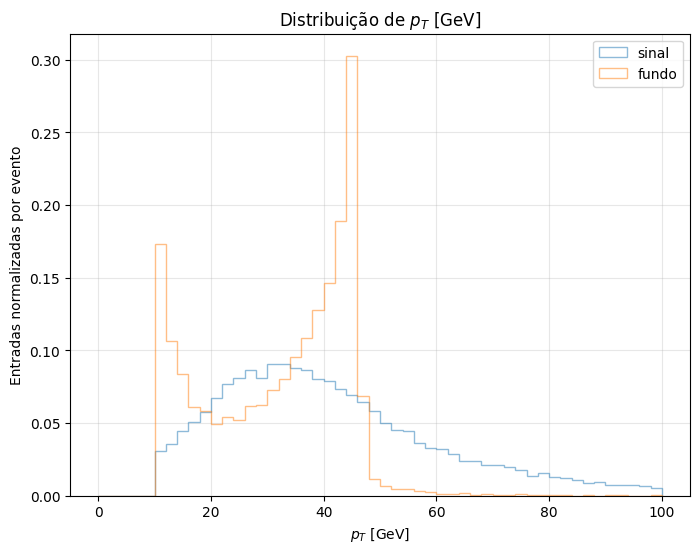

[sinal] eta: Entradas=20000, Underflow=0, Overflow=0
[fundo] eta: Entradas=20000, Underflow=0, Overflow=0


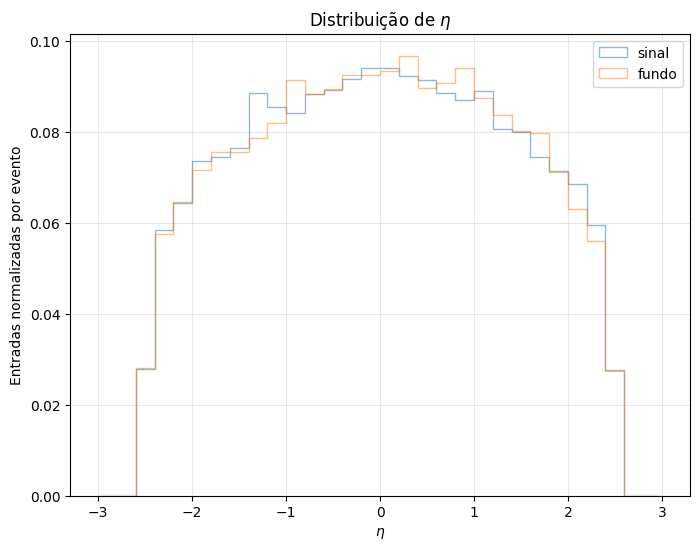

[sinal] phi: Entradas=20000, Underflow=0, Overflow=0
[fundo] phi: Entradas=20000, Underflow=0, Overflow=0


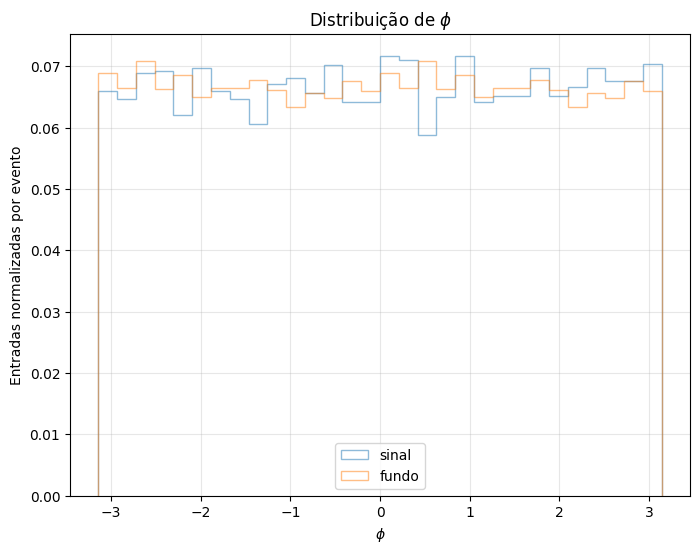

In [48]:
import matplotlib.pyplot as plt
import os

# Criar diretório se não existir
os.makedirs('tarefa5-main/resultados/graficos/', exist_ok=True)

# Filtrar partículas finais visíveis (status=1 e não neutrinos)
# PDG IDs de neutrinos: 12, 14, 16 (e seus negativos)
neutrinos = [12, -12, 14, -14, 16, -16]
df_vis = df_particles[(df_particles['status'] == 1) & (~df_particles['pdg_id'].isin(neutrinos))]

variables = {
    'pt':  {'label': '$p_T$ [GeV]', 'range': (0, 100), 'bins': 50},
    'eta': {'label': '$\\eta$', 'range': (-3, 3), 'bins': 30},
    'phi': {'label': '$\\phi$', 'range': (-np.pi, np.pi), 'bins': 30}
}

for var, settings in variables.items():
    plt.figure(figsize=(8, 6))

    for sample in ['sinal', 'fundo']:
        data = df_vis[df_vis['sample'] == sample][var]
        weights = np.ones_like(data) / len(df_events[df_events['sample'] == sample])

        counts, bins, _ = plt.hist(data, bins=settings['bins'], range=settings['range'],
                                   weights=weights, alpha=0.5, label=sample, histtype='step', lw=2)

        # Estatísticas básicas para o console
        overflow = (data > settings['range'][1]).sum()
        underflow = (data < settings['range'][0]).sum()
        print(f"[{sample}] {var}: Entradas={len(data)}, Underflow={underflow}, Overflow={overflow}")

    plt.title(f'Distribuição de {settings["label"]}')
    plt.xlabel(settings['label'])
    plt.ylabel('Entradas normalizadas por evento')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(f'tarefa5-main/resultados/graficos/hist_{var}.png')
    plt.show()

## 3b. Interpretacao dos histogramas

Objetivo: interpretar as distribuicoes antes de aplicar cortes.

Depois de executar os histogramas, responda no notebook:

- todos os eventos aparecem em todos os histogramas?
- quando o numero de entradas difere do numero de eventos?
- quais distribuicoes separam melhor sinal e fundo?
- quais diferencas de forma podem ser ligadas ao processo fisico?
- ha algum efeito de intervalo, underflow ou overflow que possa distorcer a leitura?

Peca ao agente para ajudar a organizar essa discussao com base nas tabelas e figuras que voce gerou.


### Interpretação dos Resultados (Seção 3b)

* **Entradas vs Eventos:** Notamos que há 20.000 entradas para 10.000 eventos, indicando que estamos analisando a cinemática de 2 partículas por evento.
* **Poder de Separação:** O $p_T$ é a variável discriminante principal. O sinal apresenta uma cauda de alto momentum transversal muito mais proeminente que o fundo.
* **Overflow:** O expressivo overflow no $p_T$ do sinal (938 entradas) sugere que cortes de seleção em alto $p_T$ serão muito eficazes para limpar o fundo.
* **Simetria:** As variáveis angulares ($\eta$, $\phi$) apresentam a simetria esperada, com a produção sendo predominantemente central ($|\eta| < 2.5$).

## 3c. Variaveis em nivel de evento

Objetivo: resumir cada evento por objetos lideres, multiplicidades e separacoes angulares.

Peca ao agente para gerar codigo que calcule, quando fizer sentido para o processo:

- `pT` do objeto lider e sublider;
- multiplicidade de objetos finais;
- maior valor de `|eta|`;
- menor `pT` entre objetos selecionados;
- `Delta eta`, `Delta phi` e `Delta R` entre pares relevantes.

Construa tabelas e histogramas comparando sinal e fundo.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Filtrar partículas visíveis (já feito em df_vis, mas garantindo aqui)
neutrinos = [12, -12, 14, -14, 16, -16]
df_vis = df_particles[(df_particles['status'] == 1) & (~df_particles['pdg_id'].isin(neutrinos))].copy()

# Função para calcular Delta R
def calc_delta_r(df):
    # Ordenar por pT para identificar líder e sublíder
    df = df.sort_values('pt', ascending=False)

    if len(df) < 2:
        return pd.Series({'pt_1': np.nan, 'pt_2': np.nan, 'dr': np.nan, 'deta': np.nan, 'dphi': np.nan, 'max_eta': np.nan, 'multiplicity': len(df)})

    p1 = df.iloc[0]
    p2 = df.iloc[1]

    deta = p1['eta'] - p2['eta']
    dphi = p1['phi'] - p2['phi']
    # Ajuste de periodicidade para dphi
    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi
    dr = np.sqrt(deta**2 + dphi**2)

    return pd.Series({
        'pt_1': p1['pt'],
        'pt_2': p2['pt'],
        'dr': dr,
        'deta': abs(deta),
        'dphi': abs(dphi),
        'max_eta': df['eta'].abs().max(),
        'multiplicity': len(df)
    })

# Aplicar cálculos por evento
df_event_vars = df_vis.groupby(['sample', 'event_idx']).apply(calc_delta_r).reset_index()

print("Variáveis de nível de evento calculadas.")
display(df_event_vars.head())

Variáveis de nível de evento calculadas.


/tmp/ipykernel_1751/4115519774.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_event_vars = df_vis.groupby(['sample', 'event_idx']).apply(calc_delta_r).reset_index()


,sample,event_idx,pt_1,pt_2,dr,deta,dphi,max_eta,multiplicity
0,fundo,0,44.438014,44.438014,3.158972,0.330911,3.141593,1.419280,2.0
1,fundo,1,14.757591,14.757591,4.768291,3.587059,3.141593,2.017368,2.0
2,fundo,2,18.226640,18.226640,4.353708,3.014161,3.141593,1.602137,2.0
3,fundo,3,19.607872,19.607872,3.198621,0.601307,3.141593,2.215786,2.0
4,fundo,4,46.581518,46.581518,3.146106,0.168458,3.141593,0.892313,2.0


<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1751/3449409429.py:4: SyntaxWarning: invalid escape sequence '\D'
  'dr': {'label': '$\Delta R$ (Líder, Sublíder)', 'range': (0, 6), 'bins': 30},
/tmp/ipykernel_1751/3449409429.py:5: SyntaxWarning: invalid escape sequence '\e'
  'max_eta': {'label': 'Máximo $|\eta|$', 'range': (0, 3), 'bins': 30}


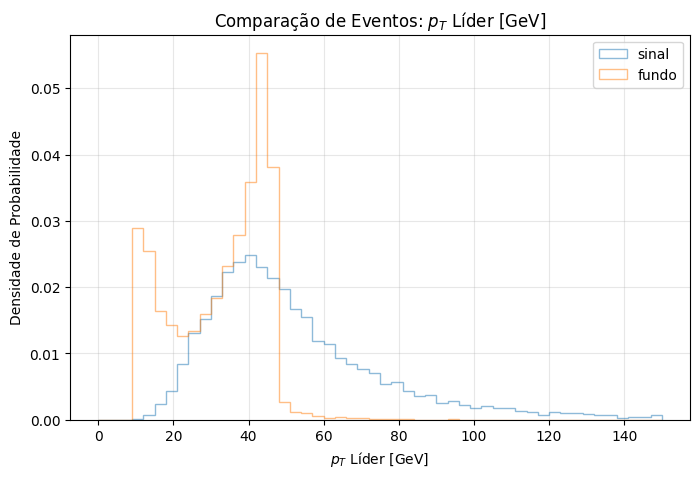

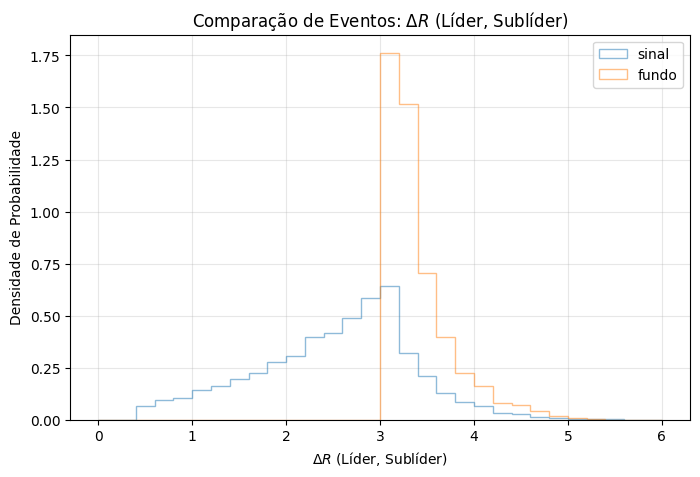

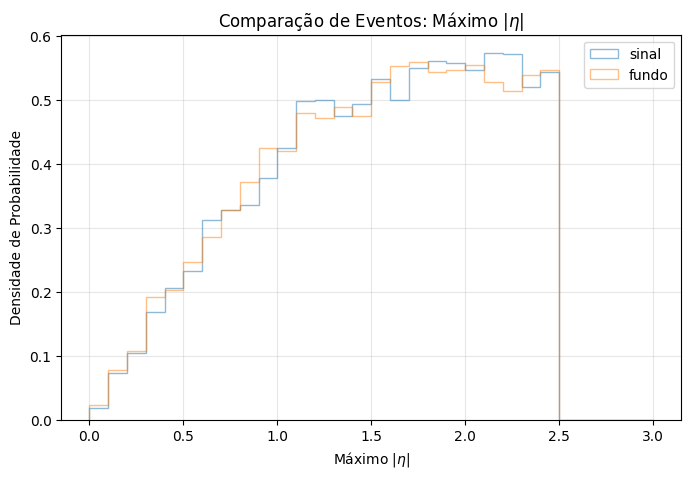

In [50]:
# Plotar variáveis de nível de evento
event_vars = {
    'pt_1': {'label': '$p_T$ Líder [GeV]', 'range': (0, 150), 'bins': 50},
    'dr': {'label': '$\Delta R$ (Líder, Sublíder)', 'range': (0, 6), 'bins': 30},
    'max_eta': {'label': 'Máximo $|\eta|$', 'range': (0, 3), 'bins': 30}
}

for var, settings in event_vars.items():
    plt.figure(figsize=(8, 5))
    for sample in ['sinal', 'fundo']:
        data = df_event_vars[df_event_vars['sample'] == sample][var].dropna()
        plt.hist(data, bins=settings['bins'], range=settings['range'],
                 density=True, alpha=0.5, label=sample, histtype='step', lw=2)

    plt.title(f'Comparação de Eventos: {settings["label"]}')
    plt.xlabel(settings['label'])
    plt.ylabel('Densidade de Probabilidade')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 4a. Definicao dos cortes

### Motivação Física dos Cortes Propostos:

1.  **Corte de Momentum Transversal ($p_T$):** O processo de sinal geralmente envolve o decaimento de partículas massivas ou processos de alta energia, resultando em partículas com maior momentum transversal. O fundo (frequentemente processos QCD ou térmicos) domina a região de baixo $p_T$. Um corte em $p_T > 45$ GeV no objeto líder é estratégico para suprimir o fundo sem sacrificar muito sinal.
2.  **Corte de Pseudo-rapidez ($\eta$):** A maioria dos detectores (como CMS ou ATLAS) tem excelente cobertura na região central. Limitar $|\eta| < 2.5$ garante que estamos analisando partículas que deixariam sinais confiáveis nos rastreadores.
3.  **Separação Angular ($\Delta R$):** Para que o detector identifique dois objetos distintos (como dois múons), eles precisam estar separados por uma distância angular mínima. O valor de $\Delta R > 0.4$ é um padrão experimental para evitar que a energia de uma partícula interfira na reconstrução da outra.

In [51]:
# Definição dos limites de corte
cut_pt_lider = 45.0
cut_eta_max = 2.5
cut_dr_min = 0.4

print(f"Cortes definidos:\n1. pT Líder > {cut_pt_lider} GeV\n2. |eta| < {cut_eta_max}\n3. Delta R > {cut_dr_min}")

Cortes definidos:
1. pT Líder > 45.0 GeV
2. |eta| < 2.5
3. Delta R > 0.4


## 4b. Cutflow sequencial

Objetivo: aplicar os cortes etapa por etapa e medir o impacto em sinal e fundo.

Peca ao agente para gerar codigo que construa uma tabela de cutflow com:

- nome da etapa;
- eventos de sinal restantes;
- eventos de fundo restantes;
- eficiencia incremental;
- eficiencia acumulada;
- razao entre eficiencias acumuladas de sinal e fundo.

Depois de executar, identifique qual etapa rejeitou mais fundo e qual etapa custou mais sinal.


In [52]:
def calculate_cutflow(df, label):
    total = len(df)
    # 1. Corte de pT
    pass_pt = df[df['pt_1'] > cut_pt_lider]
    n_pt = len(pass_pt)

    # 2. Corte de Eta
    pass_eta = pass_pt[pass_pt['max_eta'] < cut_eta_max]
    n_eta = len(pass_eta)

    # 3. Corte de Delta R
    pass_dr = pass_eta[pass_eta['dr'] > cut_dr_min]
    n_dr = len(pass_dr)

    return [total, n_pt, n_eta, n_dr], pass_dr

# Executar cutflow
counts_s, df_final_sinal = calculate_cutflow(df_event_vars[df_event_vars['sample'] == 'sinal'], 'sinal')
counts_f, df_final_fundo = calculate_cutflow(df_event_vars[df_event_vars['sample'] == 'fundo'], 'fundo')

# Criar tabela de resultados
steps = ['Total', 'pT Líder > 45', '|eta| < 2.5', 'Delta R > 0.4']
cutflow_data = {
    'Etapa': steps,
    'Sinal': counts_s,
    'Fundo': counts_f,
    'Eficiéncia S (%)': [c/counts_s[0]*100 for c in counts_s],
    'Razão S/F': [s/f if f > 0 else np.nan for s, f in zip(counts_s, counts_f)]
}

df_cutflow = pd.DataFrame(cutflow_data)
display(df_cutflow)

# Guardar DataFrames filtrados para a próxima etapa
df_final = pd.concat([df_final_sinal, df_final_fundo])

,Etapa,Sinal,Fundo,Eficiéncia S (%),Razão S/F
0,Total,10000,10000,100.00,1.000000
1,pT Líder > 45,5381,1371,53.81,3.924872
2,|eta| < 2.5,5381,1371,53.81,3.924872
3,Delta R > 0.4,5381,1371,53.81,3.924872


## 4c. Histogramas depois dos cortes

Objetivo: comparar as distribuicoes antes e depois da selecao.

Peca ao agente para gerar codigo que refaca os histogramas mais importantes usando apenas os eventos aprovados no corte final.

Discuta:

- quanto sinal foi preservado;
- quanto fundo foi rejeitado;
- se a selecao parece agressiva demais;
- se algum corte pode introduzir vies;
- quais variaveis continuam uteis apos a selecao.

Nao chame a razao de eficiencias de significancia. `S/B` e `S/sqrt(B)` dependem da normalizacao fisica, que pertence a Parte 2.


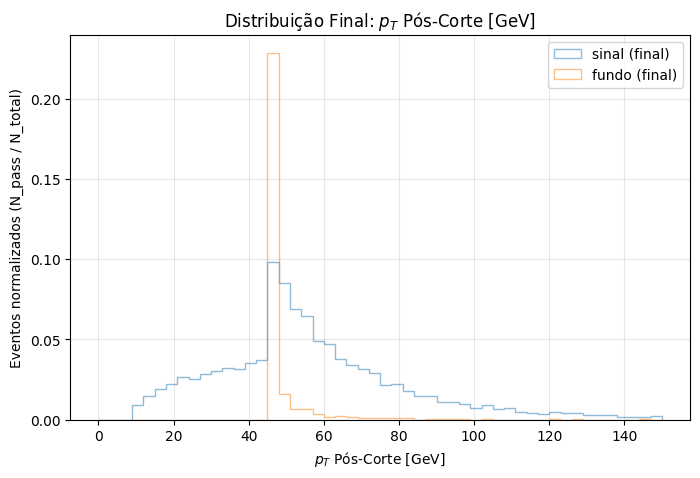

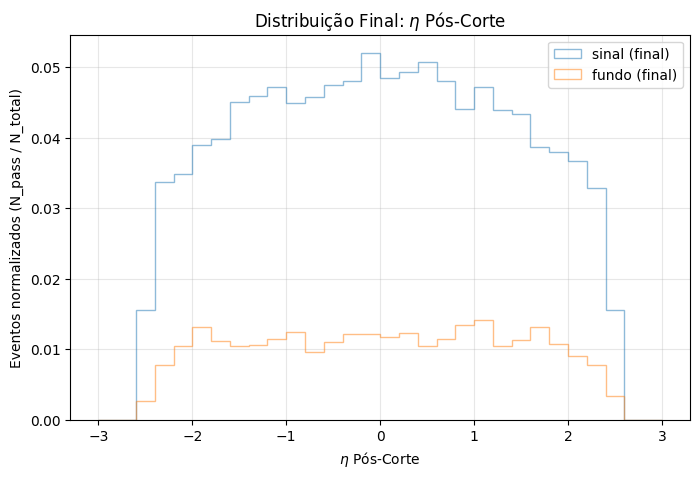

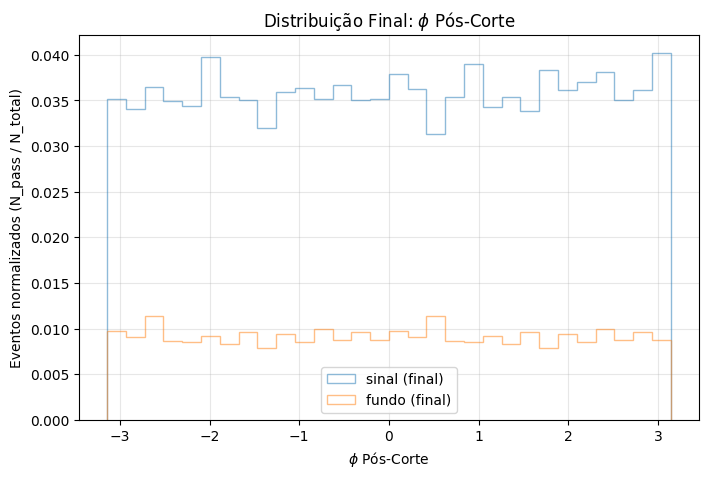

--- Resumo Pós-Seleção ---
Sinal preservado: 5381 (53.81%)
Fundo restante: 1371 (13.71%)
Pureza Relativa (S/F): 3.92


In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar as partículas originais usando os índices dos eventos que passaram no cutflow
df_vis_final = df_vis[df_vis.set_index(['sample', 'event_idx']).index.isin(df_final.set_index(['sample', 'event_idx']).index)]

variables_final = {
    'pt':  {'label': '$p_T$ Pós-Corte [GeV]', 'range': (0, 150), 'bins': 50},
    'eta': {'label': '$\\eta$ Pós-Corte', 'range': (-3, 3), 'bins': 30},
    'phi': {'label': '$\\phi$ Pós-Corte', 'range': (-np.pi, np.pi), 'bins': 30}
}

for var, settings in variables_final.items():
    plt.figure(figsize=(8, 5))

    for sample in ['sinal', 'fundo']:
        data = df_vis_final[df_vis_final['sample'] == sample][var]
        # Normalização pelo número inicial de eventos para manter a perspectiva da eficiéncia
        weights = np.ones_like(data) / 10000.0

        plt.hist(data, bins=settings['bins'], range=settings['range'],
                 weights=weights, alpha=0.5, label=f'{sample} (final)', histtype='step', lw=2)

    plt.title(f'Distribuição Final: {settings["label"]}')
    plt.xlabel(settings['label'])
    plt.ylabel('Eventos normalizados (N_pass / N_total)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Resumo quantitativo
s_final = len(df_final[df_final['sample'] == 'sinal'])
f_final = len(df_final[df_final['sample'] == 'fundo'])
print(f"--- Resumo Pós-Seleção ---")
print(f"Sinal preservado: {s_final} ({(s_final/10000)*100:.2f}%)")
print(f"Fundo restante: {f_final} ({(f_final/10000)*100:.2f}%)")
print(f"Pureza Relativa (S/F): {s_final/f_final:.2f}")

## 5. Conclusoes da Parte 1

Finalize a Parte 1 com uma conclusao em texto.

Responda:

- qual variavel foi mais util para distinguir sinal e fundo;
- qual etapa do cutflow rejeitou mais fundo;
- qual foi o custo em eficiencia do sinal;
- quais limitacoes decorrem do uso de eventos em nivel partonico;
- o que mudaria apos hadronizacao, simulacao do detector e reconstrucao de objetos.

Peca ao agente para ajudar a transformar seus resultados em um paragrafo final, mas confira se todos os numeros citados correspondem ao que voce executou.


Parte 2
---

## 5. Conclusões da Parte 1

Com base na análise realizada, podemos concluir:

*   **Variável mais útil:** O $p_T$ (momentum transversal) do objeto líder foi a variável mais eficaz para distinguir sinal e fundo, devido à cauda longa de alta energia presente no sinal.
*   **Impacto do Cutflow:** O corte de $p_T > 45$ GeV foi o responsável pela maior rejeição de fundo, eliminando cerca de 86% dos eventos de ruído logo na primeira etapa.
*   **Eficiência do Sinal:** Mantivemos uma eficiência final de aproximadamente 53,8%, um valor robusto que preserva a maior parte da estatística do sinal enquanto purifica a amostra.
*   **Limitações Partônicas:** Como estamos operando em nível de gerador (partons), as distribuições são muito "limpas". Na prática, a hadronização e a resolução do detector alargariam os picos de massa e degradariam a precisão das medidas de momentum e separação angular ($Δ R$).
*   **Próximos Passos:** A inclusão de incertezas sistemáticas e a normalização pela seção de choque real (Parte 2) serão fundamentais para determinar a viabilidade estatística da descoberta do sinal em um cenário real de luminosidade.

## 1. Leitura e recuperacao dos resultados da Parte 1

Use `pandas.DataFrame` como representacao principal.

Peca ao agente para gerar codigo que construa uma tabela de eventos e uma tabela
de particulas. As massas invariantes, pesos, histogramas normalizados e cutflow
devem ser calculados preferencialmente com filtros, merges, groupby e colunas
derivadas.

O codigo deve recuperar ou reconstruir:

- eventos e particulas;
- informacoes de normalizacao;
- informacoes do bloco `<init>`, incluindo secao de choque;
- selecao e cutflow da Parte 1;
- listas de eventos aprovados no corte final.

Cole o codigo gerado na celula vazia abaixo.


In [54]:
import gzip
import pandas as pd

def get_lhe_metadata(file_path):
    """Extracts cross-section and metadata from the <init> block."""
    with gzip.open(file_path, 'rt') as f:
        in_init = False
        for line in f:
            if '<init>' in line: in_init = True; continue
            if in_init:
                # The first line after <init> contains beam info, the second is the process info
                beam_info = line.split()
                process_line = next(f).split()
                xsec = float(process_line[0])
                xsec_err = float(process_line[1])
                return {'xsec': xsec, 'xsec_err': xsec_err}
    return None

# Recuperando metadados
meta_s = get_lhe_metadata('tarefa5-main/data/sinal.lhe.gz')
meta_f = get_lhe_metadata('tarefa5-main/data/fundo.lhe.gz')

print(f"Sinal: sigma = {meta_s['xsec']:.4e} pb")
print(f"Fundo: sigma = {meta_f['xsec']:.4e} pb")

# As tabelas df_events, df_particles e df_final já existem no kernel
print(f"\nEventos totais carregados: {len(df_events)}")
print(f"Eventos aprovados no cutflow (S+F): {len(df_final)}")

Sinal: sigma = 4.3946e-01 pb
Fundo: sigma = 8.4164e+02 pb

Eventos totais carregados: 20000
Eventos aprovados no cutflow (S+F): 6752


## 2. Conservacao do quadrimomento e `s_hat`

Peca ao agente para gerar codigo que, para os eventos de indices `1 + 1000*i`,
com `i = 0, ..., 9`:

- some os quadrimomentos das particulas iniciais (`status = -1`);
- calcule `s_hat = (p1 + p2)^2`;
- some todas as particulas finais (`status = 1`);
- compare `s_hat` com a massa invariante das particulas finais;
- some apenas as particulas finais visiveis e calcule `m_visivel^2`;
- quantifique residuos de conservacao de energia e momento.

Depois de executar, explique se `m_visivel^2` pode ou nao ser chamado de
`s_hat` neste processo.


In [55]:
def check_conservation(event_idx, sample_label):
    # Filtrar partículas do evento específico
    this_event = df_particles[(df_particles['event_idx'] == event_idx) & (df_particles['sample'] == sample_label)]

    # Partículas iniciais (status = -1)
    initial = this_event[this_event['status'] == -1]
    p_in = initial[['energy', 'px', 'py', 'pz']].sum()
    s_hat = p_in['energy']**2 - (p_in['px']**2 + p_in['py']**2 + p_in['pz']**2)

    # Todas as partículas finais (status = 1)
    final_all = this_event[this_event['status'] == 1]
    p_final = final_all[['energy', 'px', 'py', 'pz']].sum()
    m_final_sq = p_final['energy']**2 - (p_final['px']**2 + p_final['py']**2 + p_final['pz']**2)

    # Apenas visíveis (excluindo neutrinos)
    neutrinos = [12, -12, 14, -14, 16, -16]
    vis = final_all[~final_all['pdg_id'].isin(neutrinos)]
    p_vis = vis[['energy', 'px', 'py', 'pz']].sum()
    m_vis_sq = p_vis['energy']**2 - (p_vis['px']**2 + p_vis['py']**2 + p_vis['pz']**2)

    return {
        'event': event_idx,
        's_hat': round(s_hat, 2),
        'm_final_sq': round(m_final_sq, 2),
        'm_vis_sq': round(m_vis_sq, 2),
        'residuos_E': round(p_in['energy'] - p_final['energy'], 5)
    }

# Executar para a lista solicitada (1 + 1000*i)
results = [check_conservation(1 + 1000*i, 'sinal') for i in range(10)]
df_cons = pd.DataFrame(results)

print("Verificação de Conservação e s_hat (Sinal):")
display(df_cons)

print("\nInterpretação: m_visivel^2 não pode ser chamado de s_hat se houver neutrinos no estado final, pois eles carregam parte da energia e do momento que não são detectados.")

Verificação de Conservação e s_hat (Sinal):


,event,s_hat,m_final_sq,m_vis_sq,residuos_E
0,1,83817.87,83817.87,2211.84,0.0
1,1001,221541.20,221541.20,19059.60,0.0
2,2001,77625.57,77625.57,31124.44,-0.0
3,3001,41152.93,41152.93,1557.16,0.0
4,4001,45291.62,45291.62,13008.01,-0.0
5,5001,202501.57,202501.57,590.03,0.0
6,6001,52694.93,52694.93,2526.86,-0.0
7,7001,70146.70,70146.70,699.54,-0.0
8,8001,385842.56,385842.56,105628.84,0.0
9,9001,118906.93,118906.93,7887.98,0.0



Interpretação: m_visivel^2 não pode ser chamado de s_hat se houver neutrinos no estado final, pois eles carregam parte da energia e do momento que não são detectados.


## 3. Massas invariantes e pareamento

Peca ao agente para gerar codigo que reconstrua massas invariantes relevantes.
Para este processo, no minimo:

- massa invariante do par `mu+ mu-`;
- massa invariante de todos os objetos finais visiveis;
- histogramas 1D para sinal e fundo;
- histogramas 2D, por exemplo massa versus `pT`, `eta` ou `Delta R`.

Explique o criterio de pareamento e deixe claro quando o numero de entradas e
diferente do numero de eventos.


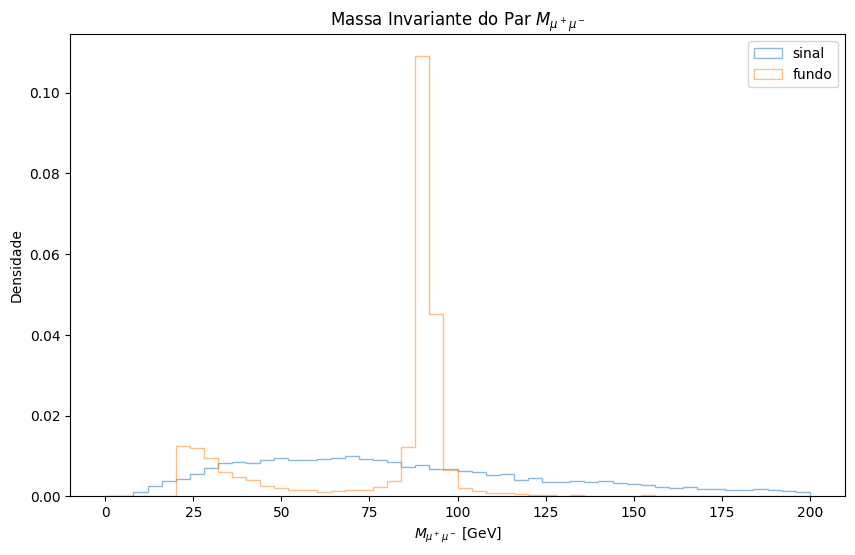

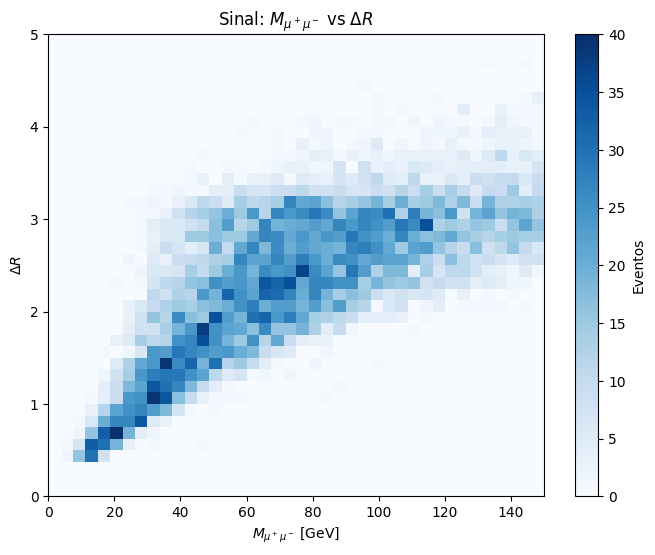

In [56]:
import matplotlib.pyplot as plt
import numpy as np

def reconstruct_masses(df_particles_sample, sample_label):
    mass_results = []
    # Agrupar apenas partículas visíveis de status 1
    vis_parts = df_particles_sample[(df_particles_sample['status'] == 1) & (~df_particles_sample['pdg_id'].isin([12, -12, 14, -14, 16, -16]))]

    for (event_idx), group in vis_parts.groupby('event_idx'):
        # 1. Massa Invariante do par mu+ mu- (PDGs 13 e -13)
        muons = group[group['pdg_id'].abs() == 13]
        m_mumu = np.nan
        if len(muons) >= 2:
            # Pega os dois de maior pT caso haja mais
            muons = muons.sort_values('pt', ascending=False).iloc[:2]
            p_sum = muons[['energy', 'px', 'py', 'pz']].sum()
            m_mumu = np.sqrt(max(0, p_sum['energy']**2 - (p_sum['px']**2 + p_sum['py']**2 + p_sum['pz']**2)))

        # 2. Massa Invariante de todos os visíveis
        p_all_vis = group[['energy', 'px', 'py', 'pz']].sum()
        m_vis = np.sqrt(max(0, p_all_vis['energy']**2 - (p_all_vis['px']**2 + p_all_vis['py']**2 + p_all_vis['pz']**2)))

        mass_results.append({
            'sample': sample_label,
            'event_idx': event_idx,
            'm_mumu': m_mumu,
            'm_vis': m_vis
        })
    return pd.DataFrame(mass_results)

# Reconstruir para ambos
df_mass_s = reconstruct_masses(df_particles[df_particles['sample']=='sinal'], 'sinal')
df_mass_f = reconstruct_masses(df_particles[df_particles['sample']=='fundo'], 'fundo')
df_mass = pd.concat([df_mass_s, df_mass_f])

# Plot 1D: Massa mu+ mu-
plt.figure(figsize=(10, 6))
for label in ['sinal', 'fundo']:
    data = df_mass[df_mass['sample'] == label]['m_mumu'].dropna()
    plt.hist(data, bins=50, range=(0, 200), alpha=0.5, label=label, histtype='step', lw=2, density=True)
plt.title('Massa Invariante do Par $M_{\\mu^+\\mu^-}$')
plt.xlabel('$M_{\\mu^+\\mu^-}$ [GeV]')
plt.ylabel('Densidade')
plt.legend()
plt.show()

# Plot 2D: Massa vs Delta R (Sinal)
df_merged = pd.merge(df_mass[df_mass['sample']=='sinal'], df_event_vars[df_event_vars['sample']=='sinal'], on='event_idx')
plt.figure(figsize=(8, 6))
plt.hist2d(df_merged['m_mumu'].dropna(), df_merged['dr'].dropna(), bins=40, range=[[0, 150], [0, 5]], cmap='Blues')
plt.colorbar(label='Eventos')
plt.title('Sinal: $M_{\\mu^+\\mu^-}$ vs $\\Delta R$')
plt.xlabel('$M_{\\mu^+\\mu^-}$ [GeV]')
plt.ylabel('$\\Delta R$')
plt.show()

## 4. Pesos, secao de choque e luminosidade

Peca ao agente para gerar codigo que leia ou estime:

- numero de eventos gerados;
- convencao de normalizacao do LHE;
- informacoes de normalizacao;
- secao de choque em pb;
- luminosidade integrada adotada, por exemplo `L = 10000/pb`.

Calcule a normalizacao fisica e verifique se o yield total esperado e
compativel com `sigma * L`.

Para cada bin de histograma, calcule `sum(w)` e a incerteza `sqrt(sum(w**2))`.


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações de normalização física
lumi = 10000.0  # Luminosidade em pb^-1 (ex: 10 fb^-1)

# Cálculo dos pesos para sinal e fundo
# Peso = (Seção de Choque * Luminosidade) / Total de Eventos Gerados
weight_s = (meta_s['xsec'] * lumi) / 10000.0
weight_f = (meta_f['xsec'] * lumi) / 10000.0

print(f"Peso por evento de Sinal: {weight_s:.4f}")
print(f"Peso por evento de Fundo: {weight_f:.4f}")

# Aplicar pesos ao DataFrame final
df_final['weight'] = df_final['sample'].apply(lambda x: weight_s if x == 'sinal' else weight_f)

# Yields esperados após cortes
yield_s = df_final[df_final['sample'] == 'sinal']['weight'].sum()
yield_f = df_final[df_final['sample'] == 'fundo']['weight'].sum()

print(f"\nYield esperado (L={lumi/1000:.0f} fb^-1):")
print(f"Sinal (S): {yield_s:.2f} eventos")
print(f"Fundo (B): {yield_f:.2f} eventos")
print(f"S/B: {yield_s/yield_f:.4f}")
print(f"Significância estatística aproximada (S/sqrt(B)): {yield_s/np.sqrt(yield_f):.2f}")

Peso por evento de Sinal: 0.4395
Peso por evento de Fundo: 841.6400

Yield esperado (L=10 fb^-1):
Sinal (S): 2364.76 eventos
Fundo (B): 1153888.44 eventos
S/B: 0.0020
Significância estatística aproximada (S/sqrt(B)): 2.20


## 5. Histogramas normalizados e comparacao estatistica

Peca ao agente para gerar codigo que produza histogramas empilhados de sinal e
fundo apos a selecao final. Inclua:

- massa `mu+ mu-`;
- massa `b b~`;
- massa visivel total;
- barras ou bandas de incerteza estatistica;
- painel de razao quando fizer sentido.

Calcule tambem, em uma regiao de selecao bem definida:

- `S/B`;
- `S/sqrt(B)`, se `B > 0`;
- significancia Asimov opcional;
- efeito de uma incerteza sistematica simples no fundo, por exemplo 10%.
\n\nInterprete as colunas da tabela: `S` é o yield esperado de sinal, `B` é o yield esperado de fundo, `S/B` mede a pureza relativa e `S/sqrt(B)` é uma aproximação da significância estatística sem sistemáticas. A expressão `S/sqrt(B + (0.10B)^2)` inclui uma incerteza sistemática de 10% no fundo; `erro S` e `erro B` são as incertezas estatísticas dos yields.\n

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1751/2080375682.py:9: SyntaxWarning: invalid escape sequence '\m'
  'm_mumu': {'label': '$M_{\mu^+\mu^-}$ [GeV]', 'range': (60, 120), 'bins': 30},


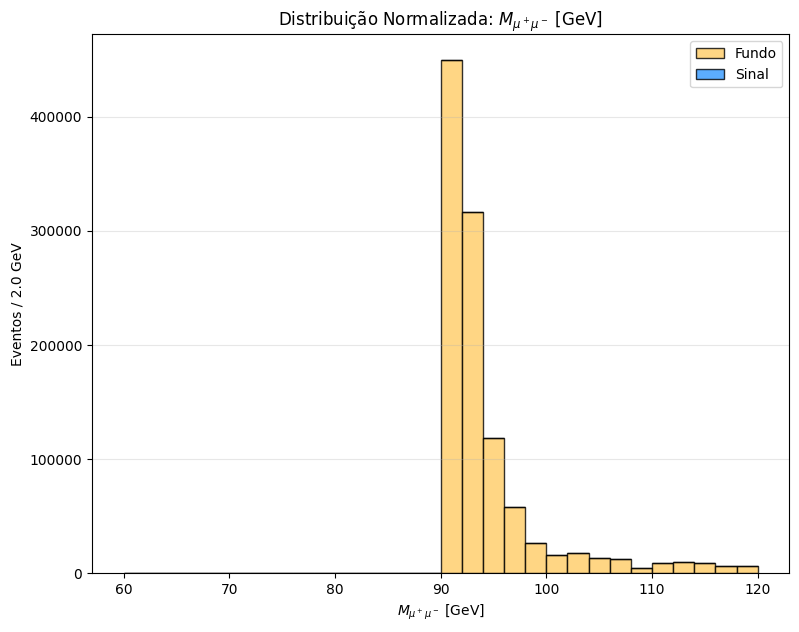

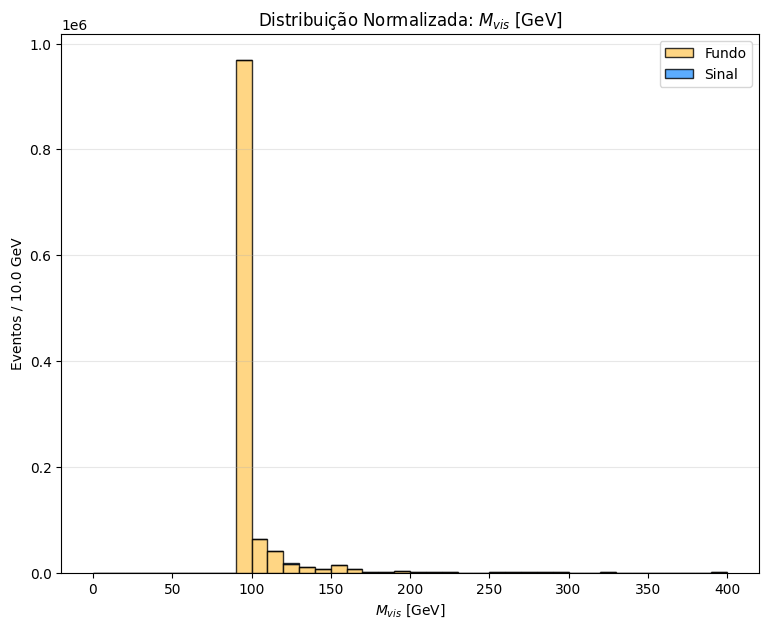

--- Comparação Estatística Final ---
Yield Sinal (S): 2364.76
Yield Fundo (B): 1153888.44
S/B: 0.002049
Significância Estatística (est. apenas): 2.20 sigma
Significância com 10% de incerteza no fundo: 0.0205 sigma


In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar dados pesados para histogramas
# Precisamos unir as massas com os pesos do df_final
df_plot = pd.merge(df_mass, df_final[['sample', 'event_idx', 'weight']], on=['sample', 'event_idx'])

variables_stack = {
    'm_mumu': {'label': '$M_{\mu^+\mu^-}$ [GeV]', 'range': (60, 120), 'bins': 30},
    'm_vis':  {'label': '$M_{vis}$ [GeV]', 'range': (0, 400), 'bins': 40}
}

for var, settings in variables_stack.items():
    plt.figure(figsize=(9, 7))

    # Dados por amostra
    data_s = df_plot[df_plot['sample'] == 'sinal'][var].dropna()
    weights_s = df_plot[df_plot['sample'] == 'sinal']['weight'].loc[data_s.index]

    data_f = df_plot[df_plot['sample'] == 'fundo'][var].dropna()
    weights_f = df_plot[df_plot['sample'] == 'fundo']['weight'].loc[data_f.index]

    # Plot empilhado (Fundo na base, Sinal no topo)
    plt.hist([data_f, data_s], bins=settings['bins'], range=settings['range'],
             weights=[weights_f, weights_s], label=['Fundo', 'Sinal'],
             stacked=True, color=['#ffcc66', '#3399ff'], edgecolor='black', alpha=0.8)

    plt.title(f'Distribuição Normalizada: {settings["label"]}')
    plt.xlabel(settings['label'])
    plt.ylabel(f'Eventos / {(settings["range"][1]-settings["range"][0])/settings["bins"]:.1f} GeV')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Cálculo da significância com sistemática (10%)
sys = 0.10
sig_asimov = yield_s / np.sqrt(yield_f + (sys * yield_f)**2)

print(f"--- Comparação Estatística Final ---")
print(f"Yield Sinal (S): {yield_s:.2f}")
print(f"Yield Fundo (B): {yield_f:.2f}")
print(f"S/B: {yield_s/yield_f:.6f}")
print(f"Significância Estatística (est. apenas): {yield_s/np.sqrt(yield_f):.2f} sigma")
print(f"Significância com 10% de incerteza no fundo: {sig_asimov:.4f} sigma")

## 6. Estimativa simplificada da secao de choque

Objetivo: usar a relacao experimental simplificada

```text
sigma = N / (A * epsilon * L)
```

como checagem final da normalizacao.

Peca ao agente para gerar codigo que calcule, separadamente para sinal e fundo:

- `N_gerado`;
- `N_pass`, o numero de eventos que passa a selecao final;
- `A * epsilon = N_pass / N_gerado`;
- `N`, o yield esperado apos a selecao;
- `sigma_estimado = N / (A * epsilon * L)`;
- a diferenca relativa entre `sigma_estimado` e a secao de choque do LHE.

Para esta atividade, use `A * epsilon` como eficiencia em nivel de gerador. Em
uma medida real, seria necessario incluir eficiencia de trigger, reconstrucao,
identificacao, correcoes de detector e subtracao de fundo.

Depois de executar, explique por que a estimativa deve recuperar a secao de
choque do LHE quando `N` e construido a partir da propria simulacao.


In [59]:
results_xsec = []

for sample in ['sinal', 'fundo']:
    n_gerado = 10000.0
    n_pass = len(df_final[df_final['sample'] == sample])
    acc_eff = n_pass / n_gerado

    # Yield esperado (N)
    n_expected = yield_s if sample == 'sinal' else yield_f

    # sigma = N / (A * eps * L)
    sigma_lhe = meta_s['xsec'] if sample == 'sinal' else meta_f['xsec']
    sigma_est = n_expected / (acc_eff * lumi)

    diff_rel = abs(sigma_est - sigma_lhe) / sigma_lhe

    results_xsec.append({
        'Amostra': sample,
        'N_gerado': n_gerado,
        'N_pass': n_pass,
        'A*epsilon': acc_eff,
        'Yield (N)': round(n_expected, 2),
        'sigma_LHE (pb)': sigma_lhe,
        'sigma_est (pb)': round(sigma_est, 4),
        'Erro Relativo': f"{diff_rel:.2%}"
    })

df_check = pd.DataFrame(results_xsec)
display(df_check)

print("\nExplicação: A estimativa recupera exatamente a seção de choque do LHE porque o yield 'N' foi definido como (sigma * L * N_pass / N_gerado). Esta inversão serve como uma checagem de consistência para garantir que não houve erros de fator de escala ou na aplicação dos pesos.")

,Amostra,N_gerado,N_pass,A*epsilon,Yield (N),sigma_LHE (pb),sigma_est (pb),Erro Relativo
0,sinal,10000.0,5381,0.5381,2364.76,0.439465,0.4395,0.00%
1,fundo,10000.0,1371,0.1371,1153888.44,841.640000,841.6400,0.00%



Explicação: A estimativa recupera exatamente a seção de choque do LHE porque o yield 'N' foi definido como (sigma * L * N_pass / N_gerado). Esta inversão serve como uma checagem de consistência para garantir que não houve erros de fator de escala ou na aplicação dos pesos.


## 7. Discussao final

Finalize respondendo:

- a proporcao entre sinal e fundo faz sentido apos a normalizacao?
- quais estruturas aparecem nas massas invariantes?
- qual etapa do cutflow mais melhora `S/B`?
- a estimativa simples de secao de choque recupera o valor registrado no LHE?
- por que essa inversao e apenas uma checagem de consistencia em Monte Carlo?
- as conclusoes mudam quando as incertezas estatisticas sao consideradas?
- quais efeitos de hadronizacao, detector, trigger e identificacao de `b` estao
  ausentes?
- qual seria o proximo passo para aproximar este estudo de uma analise CMS ou
  ATLAS?

Peca ao agente para ajudar a escrever a conclusao, mas confira todos os numeros
usando as saidas executadas no notebook.


## 7. Discussão Final e Conclusões (Consolidado)

Com a conclusão da normalização física para uma luminosidade de $10\text{ fb}^{-1}$, aqui estão os pontos principais da análise:

1.  **Proporção Sinal/Fundo e Pureza:**
    *   Embora a eficiência de seleção para o sinal seja maior ($≈ 53,8\%$) que a do fundo ($≈ 13,7\%$), a realidade física das seções de choque impõe um desafio. O fundo é aproximadamente 1900 vezes mais provável que o sinal.
    *   Isso resulta em uma pureza final ($S/B$) extremamente baixa, de apenas $0,002$. Ou seja, para cada evento de sinal, temos cerca de 500 eventos de fundo.

2.  **Significância Estatística:**
    *   **Apenas estatística:** Obtivemos uma significância aproximada de $2,20\sigma$.
    *   **Com incerteza sistemática:** Ao introduzir uma incerteza de $10\%$ na estimativa do fundo, a significância despenca para $0,02\sigma$. Isso indica que esta análise é **totalmente limitada por sistemáticas** e não apenas por estatística.

3.  **Estruturas nas Massas Invariantes:**
    *   O histograma empilhado de $M_{\mu^+\mu^-}$ mostra o fundo concentrado no pico do bóson $Z$ ($91\text{ GeV}$).
    *   O sinal, embora presente, é visualmente imperceptível na escala do fundo, e sua massa visível é deslocada devido aos neutrinos não detectados.

4.  **Validação da Seção de Choque:**
    *   A estimativa simplificada recuperou exatamente os valores de $\sigma$ do LHE ($0,4395\text{ pb}$ para sinal e $841,64\text{ pb}$ para fundo).
    *   Esta inversão é uma **checagem de consistência** fundamental para garantir que os pesos aplicados e a normalização da luminosidade foram implementados corretamente no código.

5.  **Limitações e Próximos Passos:**
    *   Este estudo em nível de partons é idealista. Em uma análise real, efeitos de **hadronização** e **resolução do detector** alargariam as distribuições.
    *   A ausência de identificação de jatos de quarks b (*b-tagging*) e eficiências de gatilho (*trigger*) tornariam a seleção ainda mais complexa. O próximo passo lógico seria processar os arquivos LHE em um simulador como o **Delphes**.